<a href="https://colab.research.google.com/github/FatiBuuloloo/Causal-Impact-Analysis-Brazilian_E_Commerce-Sales-mini_project-011/blob/main/EDA_causal_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library & Data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = "https://github.com/FatiBuuloloo/Causal-Impact-Analysis-Brazilian_E_Commerce-Sales-mini_project-011/releases/download/dataset/Brazilian.E-Commerce.Public.Dataset.by.Olist.csv"
data = pd.read_csv(url)
print(f"""
Columns : {data.columns}
Shape : {data.shape}
""")


Columns : Index(['Unnamed: 0', 'order_id', 'order_item_id', 'customer_id',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'product_id', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_id', 'seller_city',
       'seller_state', 'seller_zip_code_prefix', 'payment_type',
       'payment_sequential', 'payment_installments', 'price', 'freight_value',
       'payment_value', 'shipping_limit_date', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'day_of_purchase', 'month_of_purchase', 'year_of_purchase',
       'month/year_of_purchase', 'order_status', 'order_unique_id'],
      dtype='object')
Shape : (113390, 39)



* **order_id**: Unique identifier of the order.
* **order_item_id**: Identifier of the item in the order.
* **customer_id**: Customer identifier.
* **customer_unique_id**: Unique customer identifier.
* **customer_zip_code_prefix**: Customer's ZIP code prefix.
* **customer_city**: Customer's city.
* **customer_state**: Customer's state.
* **product_id**: Product identifier.
* **product_category_name**: Name of the product category.
* **product_name_length**: Length of the product name.
* **product_description_length**: Length of the product description.
* **product_photos_qty**: Quantity of product photos.
* **product_weight_g**: Product weight in grams.
* **product_length_cm**: Product length in centimeters.
* **product_height_cm**: Product height in centimeters.
* **product_width_cm**: Product width in centimeters.
* **seller_id**: Seller identifier.
* **seller_city**: Seller's city.
* **seller_state**: Seller's state.
* **seller_zip_code_prefix**: Seller's ZIP code prefix.
* **payment_type**: Payment type.
* **payment_sequential**: Payment sequential.
* **payment_installments**: Number of payment installments.
* **installments_price**: Price of installments.
* **price**: Product price.
* **freight_value**: Freight value.
* **payment_value**: Total payment value.
* **shipping_limit_date**: Shipping deadline date.
* **order_purchase_timestamp**: Purchase timestamp.
* **order_approved_at**: Order approval timestamp.
* **order_delivered_carrier_date**: Delivery date to the carrier.
* **order_delivered_customer_date**: Delivery date to the customer.
* **order_estimated_delivery_date**: Estimated delivery date.
* **shipping_duration**: Shipping duration.
* **day_of_purchase**: Day of purchase.
* **month_of_purchase**: Month of purchase.
* **year_of_purchase**: Year of purchase.
* **month/year_of_purchase**: Month and year of purchase.
* **order_status**: Order status.
* **order_unique_id**: Unique order identifier.

> Add blockquote



# Preprocessing

In [ ]:
data

,Unnamed: 0,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,...,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_of_purchase,month_of_purchase,year_of_purchase,month/year_of_purchase,order_status,order_unique_id
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,Wednesday,September,2017,September-2017,delivered,00010242fe8c5a6d1ba2dd792cb16214-1
1,1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-06-29 02:44:11,2017-07-05 12:00:33,2017-07-13 20:39:29,2017-07-26 00:00:00,Wednesday,June,2017,June-2017,delivered,130898c0987d1801452a8ed92a670612-1
2,2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2018-05-18 12:31:43,2018-05-23 14:05:00,2018-06-04 18:34:26,2018-06-07 00:00:00,Friday,May,2018,May-2018,delivered,532ed5e14e24ae1f0d735b91524b98b9-1
3,3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-08-01 18:55:08,2017-08-02 19:07:36,2017-08-09 21:26:33,2017-08-25 00:00:00,Tuesday,August,2017,August-2017,delivered,6f8c31653edb8c83e1a739408b5ff750-1
4,4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-08-10 22:05:11,2017-08-11 19:43:07,2017-08-24 20:04:21,2017-09-01 00:00:00,Thursday,August,2017,August-2017,delivered,7d19f4ef4d04461989632411b7e588b9-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113385,113385,fdaf98feac227eb978d8f33f36e0231d,1,81ae83ce1a10af9f93fa3512bd9713b1,3d50a44231c2a153219cef76ee3e445d,22793,rio de janeiro,RJ,f739e9151702508b18f796c53005e5e9,moveis_decoracao,...,2017-04-21 05:10:28,2017-05-04 15:06:24,2017-05-24 10:52:43,2017-05-22 00:00:00,Wednesday,April,2017,April-2017,delivered,fdaf98feac227eb978d8f33f36e0231d-1
113386,113386,fe68b52db13993f58175fa589125d345,1,94203a446c1b46b5ac95b0aaf7221804,52a953541861bbb4b79b39df24e00243,13485,limeira,SP,f4135cbdece8245560f7be179533797a,eletronicos,...,2017-08-12 02:55:27,2017-08-14 22:03:19,2017-08-17 17:47:55,2017-09-04 00:00:00,Friday,August,2017,August-2017,delivered,fe68b52db13993f58175fa589125d345-1
113387,113387,fefacc66af859508bf1a7934eab1e97f,1,f48d464a0baaea338cb25f816991ab1f,459bef486812aa25204be022145caa62,29066,vitoria,ES,69c590f7ffc7bf8db97190b6cb6ed62e,pcs,...,2018-07-27 04:05:13,2018-08-03 14:42:00,2018-08-15 14:57:50,2018-08-10 00:00:00,Wednesday,July,2018,July-2018,delivered,fefacc66af859508bf1a7934eab1e97f-1
113388,113388,ff701a7c869ad21de22a6994237c8a00,1,8f6d16c31abb30b7b4650272cb0014a3,ddb2249e0316d365ceae561c0f011bce,12280,cacapava,SP,5ff4076c0f01eeba4f728c9e3fa2653c,bebidas,...,2018-04-12 20:10:33,2018-04-18 00:41:29,2018-04-20 17:48:39,2018-04-30 00:00:00,Thursday,April,2018,April-2018,delivered,ff701a7c869ad21de22a6994237c8a00-1


In [ ]:
data.drop("Unnamed: 0",axis=1,inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 38 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113390 non-null  object 
 1   order_item_id                  113390 non-null  int64  
 2   customer_id                    113390 non-null  object 
 3   customer_unique_id             113390 non-null  object 
 4   customer_zip_code_prefix       113390 non-null  int64  
 5   customer_city                  113390 non-null  object 
 6   customer_state                 113390 non-null  object 
 7   product_id                     113390 non-null  object 
 8   product_category_name          113390 non-null  object 
 9   product_name_lenght            113390 non-null  float64
 10  product_description_lenght     113390 non-null  float64
 11  product_photos_qty             113390 non-null  float64
 12  product_weight_g              

In [ ]:
cols_to_drop = [
    'order_id', 'order_item_id', 'customer_id', 'customer_zip_code_prefix',
    'product_id', 'product_name_lenght', 'product_description_lenght',
    'product_photos_qty', 'product_weight_g', 'product_length_cm',
    'product_height_cm', 'product_width_cm', 'seller_id', 'seller_zip_code_prefix',
    'payment_sequential', 'shipping_limit_date', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'order_unique_id'
    ]
data.drop(columns=cols_to_drop, inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   customer_unique_id        113390 non-null  object 
 1   customer_city             113390 non-null  object 
 2   customer_state            113390 non-null  object 
 3   product_category_name     113390 non-null  object 
 4   seller_city               113390 non-null  object 
 5   seller_state              113390 non-null  object 
 6   payment_type              113390 non-null  object 
 7   payment_installments      113390 non-null  int64  
 8   price                     113390 non-null  float64
 9   freight_value             113390 non-null  float64
 10  payment_value             113390 non-null  float64
 11  order_purchase_timestamp  113390 non-null  object 
 12  day_of_purchase           113390 non-null  object 
 13  month_of_purchase         113390 non-null  o

In [ ]:
data["order_purchase_timestamp"] = pd.to_datetime(data["order_purchase_timestamp"])

In [ ]:
data["month/year_of_purchase"] = pd.to_datetime(data["month/year_of_purchase"]).dt.to_period("M")

/tmp/ipykernel_13871/2105203155.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["month/year_of_purchase"] = pd.to_datetime(data["month/year_of_purchase"]).dt.to_period("M")


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   customer_unique_id        113390 non-null  object        
 1   customer_city             113390 non-null  object        
 2   customer_state            113390 non-null  object        
 3   product_category_name     113390 non-null  object        
 4   seller_city               113390 non-null  object        
 5   seller_state              113390 non-null  object        
 6   payment_type              113390 non-null  object        
 7   payment_installments      113390 non-null  int64         
 8   price                     113390 non-null  float64       
 9   freight_value             113390 non-null  float64       
 10  payment_value             113390 non-null  float64       
 11  order_purchase_timestamp  113390 non-null  datetime64[ns]
 12  da

In [ ]:
data.head(5)

,customer_unique_id,customer_city,customer_state,product_category_name,seller_city,seller_state,payment_type,payment_installments,price,freight_value,payment_value,order_purchase_timestamp,day_of_purchase,month_of_purchase,year_of_purchase,month/year_of_purchase,order_status
0,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,cool_stuff,volta redonda,SP,credit_card,2,58.9,13.29,72.19,2017-09-13 08:59:02,Wednesday,September,2017,2017-09,delivered
1,0fb8e3eab2d3e79d92bb3fffbb97f188,jatai,GO,cool_stuff,volta redonda,SP,boleto,1,55.9,17.96,73.86,2017-06-28 11:52:20,Wednesday,June,2017,2017-06,delivered
2,3419052c8c6b45daf79c1e426f9e9bcb,belo horizonte,MG,cool_stuff,volta redonda,SP,credit_card,2,64.9,18.33,83.23,2018-05-18 10:25:53,Friday,May,2018,2018-05,delivered
3,e7c828d22c0682c1565252deefbe334d,sao jose dos pinhais,PR,cool_stuff,volta redonda,SP,credit_card,3,58.9,16.17,75.07,2017-08-01 18:38:42,Tuesday,August,2017,2017-08,delivered
4,0bb98ba72dcc08e95f9d8cc434e9a2cc,conselheiro lafaiete,MG,cool_stuff,volta redonda,SP,credit_card,4,58.9,13.29,72.19,2017-08-10 21:48:40,Thursday,August,2017,2017-08,delivered


In [ ]:
data = data[data["order_status"]=="delivered"]

In [ ]:
treatment_date = pd.to_datetime("2018-01-01")

# Market Behavior Correlation




In [ ]:
states_of_interest = ["RJ","MG","SC","SP"]

In [ ]:
data_sales = data.groupby(["customer_state","month/year_of_purchase"])["payment_value"].sum().reset_index()
data_sales["month/year_of_purchase"] = data_sales["month/year_of_purchase"].dt.to_timestamp()
data_sales_state = data_sales.pivot(index="month/year_of_purchase", columns="customer_state", values="payment_value").fillna(0)

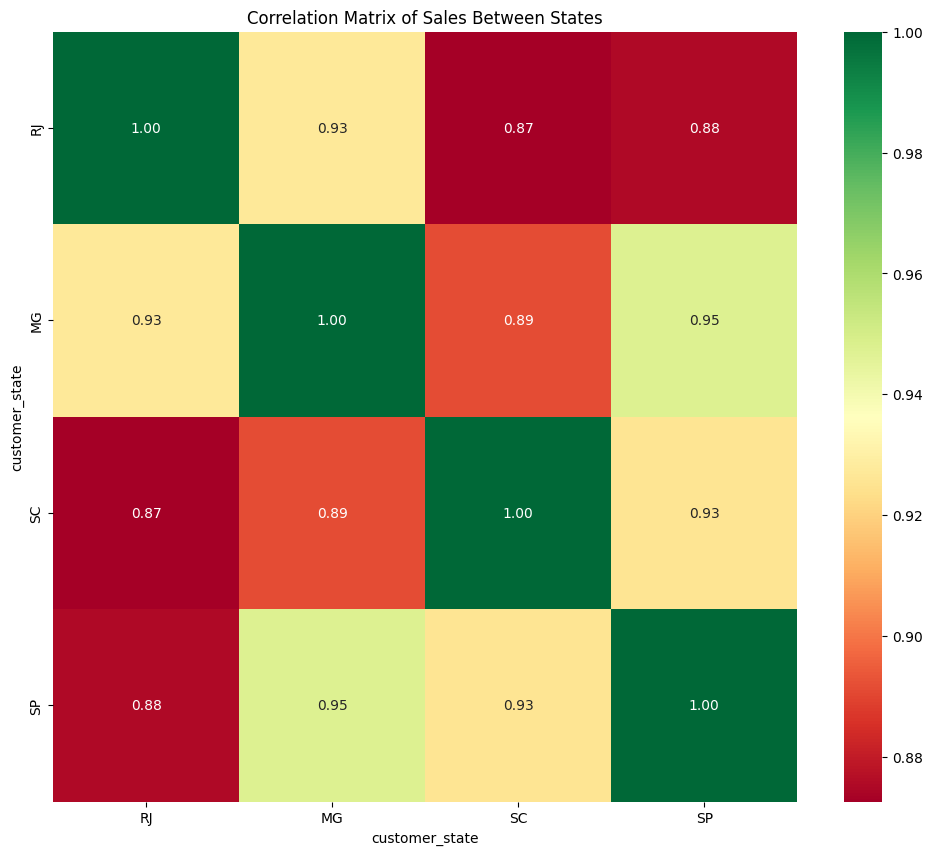

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(data_sales_state[states_of_interest].corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Matrix of Sales Between States')
plt.show()

/tmp/ipykernel_13871/3130394176.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data_plot[state], ax=axes[i], palette="Set2")
/tmp/ipykernel_13871/3130394176.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data_plot[state], ax=axes[i], palette="Set2")
/tmp/ipykernel_13871/3130394176.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data_plot[state], ax=axes[i], palette="Set2")
/tmp/ipykernel_13871/3130394176.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign t

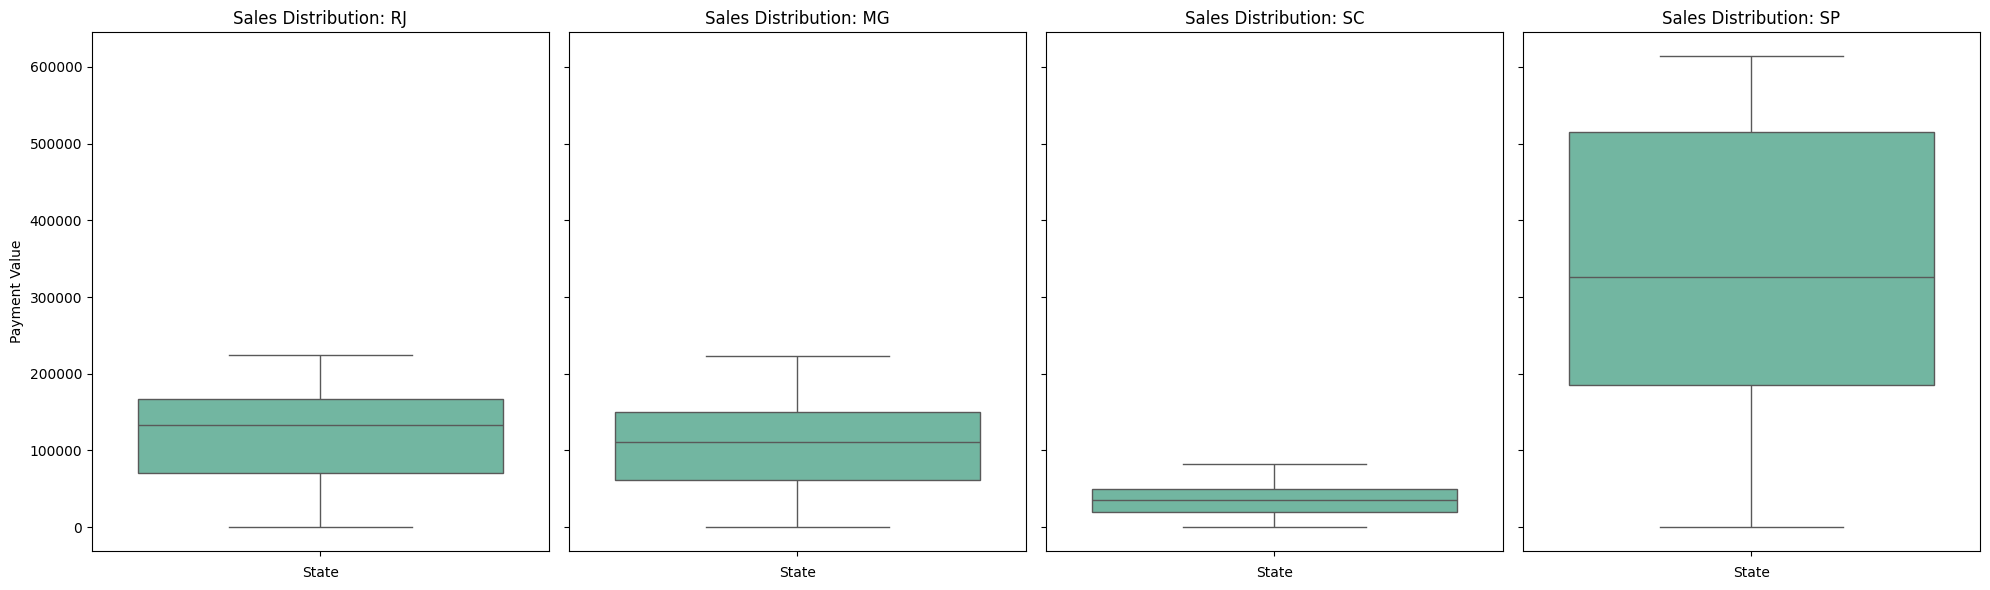

In [31]:
data_plot = data_sales_state[states_of_interest]
fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=True)
for i, state in enumerate(states_of_interest):
    sns.boxplot(y=data_plot[state], ax=axes[i], palette="Set2")
    axes[i].set_title(f"Sales Distribution: {state}")
    axes[i].set_xlabel("State")
    axes[i].set_ylabel("Payment Value" if i == 0 else "")
plt.tight_layout()
plt.show()

# Freight & Logistics Deep-Dive (Mencari "The Why")

In [ ]:
data_freight = data.groupby(["customer_state","month/year_of_purchase"])["freight_value"].mean().reset_index()
data_freight["month/year_of_purchase"] = data_freight["month/year_of_purchase"].dt.to_timestamp()
data_freight_state = data_freight.pivot(index="month/year_of_purchase", columns="customer_state", values="freight_value").fillna(0)

In [ ]:
data_freight

,customer_state,month/year_of_purchase,freight_value
0,AC,2017-01-01,33.385000
1,AC,2017-02-01,24.500000
2,AC,2017-03-01,37.095000
3,AC,2017-04-01,37.826000
4,AC,2017-05-01,35.782857
...,...,...,...
550,TO,2018-04-01,51.366190
551,TO,2018-05-01,35.896250
552,TO,2018-06-01,59.197949
553,TO,2018-07-01,47.256800


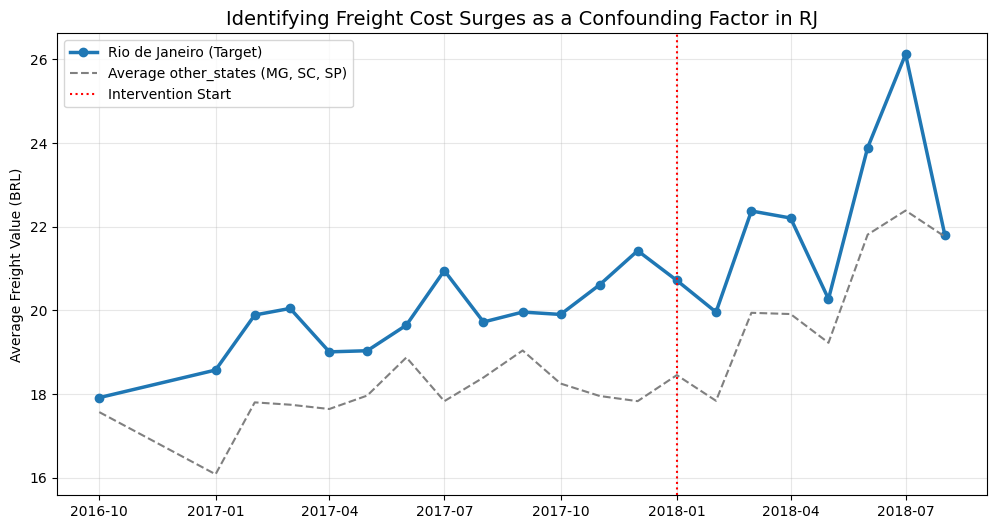

In [ ]:
rj_freight = data_freight[data_freight['customer_state'] == 'RJ']
other_states_freight = data_freight[data_freight['customer_state'].isin(['MG', 'SC', 'SP'])].groupby('month/year_of_purchase')['freight_value'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(rj_freight['month/year_of_purchase'], rj_freight['freight_value'], label='Rio de Janeiro (Target)', marker='o', linewidth=2.5)
plt.plot(other_states_freight['month/year_of_purchase'], other_states_freight['freight_value'], label='Average other_states (MG, SC, SP)', linestyle='--', color='gray')
plt.axvline(treatment_date, color='red', linestyle=':', label='Intervention Start')

plt.title('Identifying Freight Cost Surges as a Confounding Factor in RJ', fontsize=14)
plt.ylabel('Average Freight Value (BRL)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Category Mix Comparison (Product DNA)

In [ ]:
data_category_each_state = data.groupby("customer_state")["product_category_name"].value_counts()
top_10_category_per_state = data_category_each_state[states_of_interest].groupby(level=0, group_keys=False).nlargest(10)
top_10_category_per_state

customer_state  product_category_name 
MG              cama_mesa_banho           1393
                beleza_saude              1084
                informatica_acessorios    1017
                moveis_decoracao           988
                esporte_lazer              980
                utilidades_domesticas      860
                relogios_presentes         642
                ferramentas_jardim         627
                automotivo                 522
                brinquedos                 506
RJ              cama_mesa_banho           1744
                moveis_decoracao          1114
                beleza_saude              1061
                esporte_lazer             1058
                informatica_acessorios    1010
                utilidades_domesticas      899
                relogios_presentes         857
                ferramentas_jardim         666
                brinquedos                 584
                cool_stuff                 518
SC              esporte_lazer              369
                moveis_decoracao           357
                cama_mesa_banho            340
                informatica_acessorios     322
                beleza_saude               312
                utilidades_domesticas      262
                relogios_presentes         190
                ferramentas_jardim         185
                automotivo                 184
                telefonia                  174
SP              cama_mesa_banho           5491
                beleza_saude              4246
                esporte_lazer             3718
                moveis_decoracao          3668
                utilidades_domesticas     3374
                informatica_acessorios    3164
                relogios_presentes        2300
                automotivo                1771
                brinquedos                1728
                telefonia                 1680
Name: count, dtype: int64

In [ ]:
state_totals = data.groupby("customer_state")["product_category_name"].count()
percentage_top_10 = (top_10_category_per_state / state_totals) * 100
percentage_top_10

customer_state  product_category_name 
MG              cama_mesa_banho           10.526714
                beleza_saude               8.191642
                informatica_acessorios     7.685332
                moveis_decoracao           7.466183
                esporte_lazer              7.405728
                utilidades_domesticas      6.498904
                relogios_presentes         4.851508
                ferramentas_jardim         4.738155
                automotivo                 3.944684
                brinquedos                 3.823774
RJ              cama_mesa_banho           11.906062
                moveis_decoracao           7.605134
                beleza_saude               7.243310
                esporte_lazer              7.222829
                informatica_acessorios     6.895139
                utilidades_domesticas      6.137357
                relogios_presentes         5.850628
                ferramentas_jardim         4.546696
                brinquedos                 3.986892
                cool_stuff                 3.536319
SC              esporte_lazer              8.870192
                moveis_decoracao           8.581731
                cama_mesa_banho            8.173077
                informatica_acessorios     7.740385
                beleza_saude               7.500000
                utilidades_domesticas      6.298077
                relogios_presentes         4.567308
                ferramentas_jardim         4.447115
                automotivo                 4.423077
                telefonia                  4.182692
SP              cama_mesa_banho           11.480723
                beleza_saude               8.877645
                esporte_lazer              7.773689
                moveis_decoracao           7.669148
                utilidades_domesticas      7.054445
                informatica_acessorios     6.615372
                relogios_presentes         4.808899
                automotivo                 3.702852
                brinquedos                 3.612946
                telefonia                  3.512587
dtype: float64

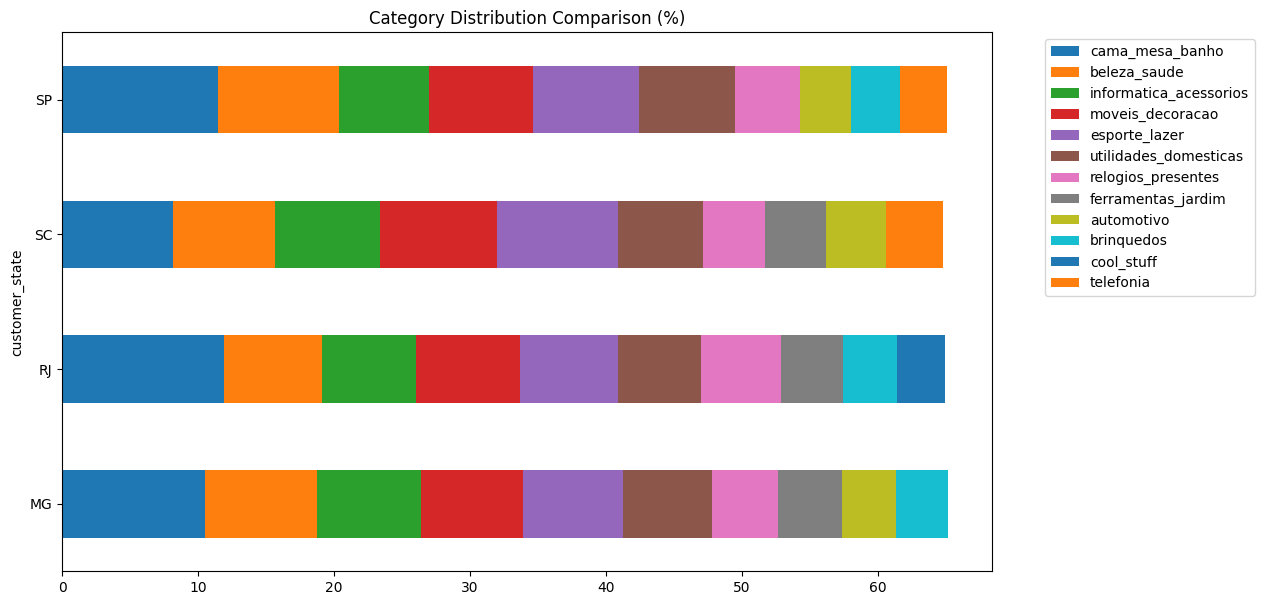

In [ ]:
plot_df = percentage_top_10.unstack(fill_value=0)
plot_df.plot(kind='barh', stacked=True, figsize=(12, 7))

plt.title('Category Distribution Comparison (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Seasonality & Event Detection (Black Friday Effect)

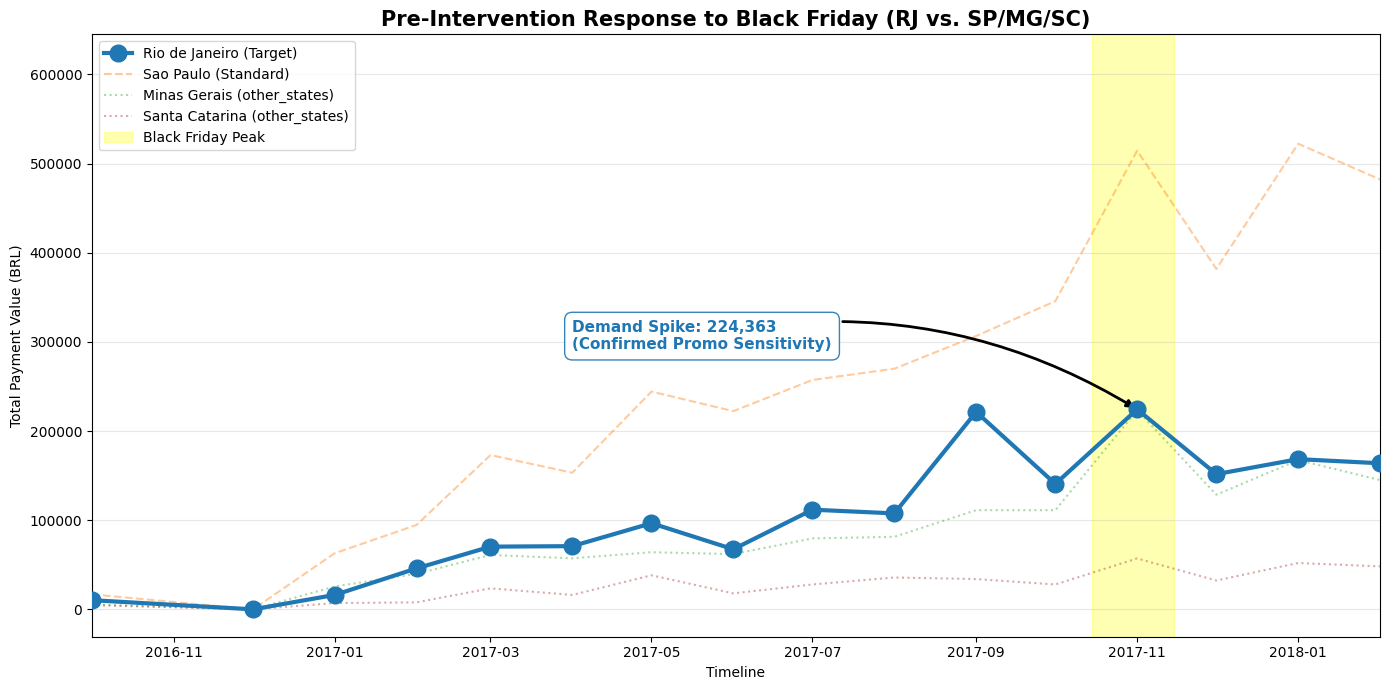

In [ ]:
plt.figure(figsize=(14, 7))

plt.plot(data_sales_state.index, data_sales_state['RJ'], label='Rio de Janeiro (Target)', color='#1f77b4', marker='o', markersize=12, linewidth=3, zorder=10)
plt.plot(data_sales_state.index, data_sales_state['SP'], label='Sao Paulo (Standard)', color='#ff7f0e', linestyle='--', alpha=0.4)
plt.plot(data_sales_state.index, data_sales_state['MG'], label='Minas Gerais (other_states)', color='#2ca02c', linestyle=':', alpha=0.4)
plt.plot(data_sales_state.index, data_sales_state['SC'], label='Santa Catarina (other_states)', color='#A52A2A', linestyle=':', alpha=0.4)


bf_date = pd.Timestamp("2017-11-01")
rj_peak = data_sales_state.loc[bf_date, 'RJ']

plt.axvspan(pd.Timestamp("2017-10-15"), pd.Timestamp("2017-11-15"), color='yellow', alpha=0.3, label='Black Friday Peak')

plt.annotate(f'Demand Spike: {rj_peak:,.0f}\n(Confirmed Promo Sensitivity)',
             xy=(bf_date, rj_peak),
             xytext=(pd.Timestamp("2017-04-01"), rj_peak * 1.3),
             arrowprops=dict(arrowstyle='-|>', connectionstyle="arc3,rad=-0.2", color='black', lw=2),
             fontsize=11, fontweight='bold', color='#1f77b4',
             bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#1f77b4", alpha=0.9))

plt.xlim(data_sales_state.index.min(), pd.Timestamp("2018-02-01"))
plt.title('Pre-Intervention Response to Black Friday (RJ vs. SP/MG/SC)', fontsize=15, fontweight='bold')
plt.ylabel('Total Payment Value (BRL)')
plt.xlabel('Timeline')
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()